In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [2]:
data = np.load("1d-n-effect.npz")

t = data["times"]
psi_n5 = data["psi_n5"]  
psi_n8 = data["psi_n8"]
psi_n11 = data["psi_n11"]
psi_exact_n5 = data["psi_exact_n5"]  
psi_exact_n8 = data["psi_exact_n8"]
psi_exact_n11 = data["psi_exact_n11"]

error_n5 = data["rel_l2_err_n5"]
error_n8 = data["rel_l2_err_n8"]
error_n11 = data["rel_l2_err_n11"]

In [ ]:
n = 5                                                   
N = 2**n                                             
x_max = 10
x_n5 = np.linspace(-x_max, x_max, N)
n = 8                                                   
N = 2**n                                              
x_max = 10
x_n8 = np.linspace(-x_max, x_max, N)
n = 11                                                  
N = 2**n                                               
x_max = 10
x_n11 = np.linspace(-x_max, x_max, N)

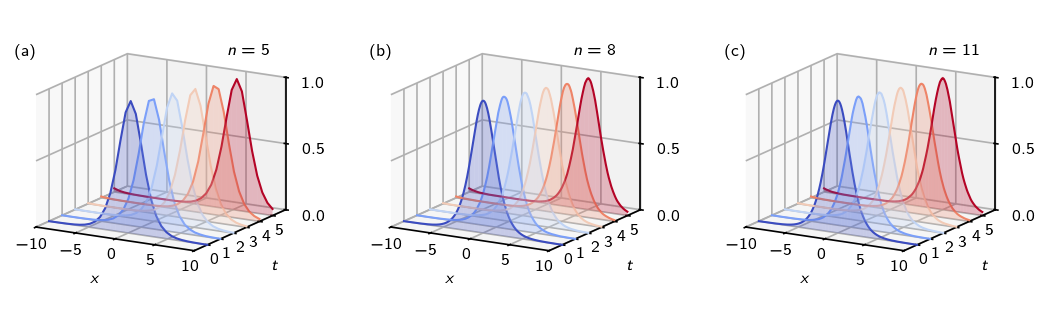

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


fontsize = 8
dt = 0.01
t_values = [0, 1, 2, 3, 4, 5]


width = 17.9 / 2.54
height = width * 0.35

fig, axes = plt.subplots(
    1, 3,
    figsize=(width, height),
    subplot_kw={'projection': '3d'}
)

cmap = plt.get_cmap('coolwarm')
colors = [cmap(i / (len(t_values) - 1)) for i in range(len(t_values))]


def plot_panel(
    ax,
    x,
    psi_line,
    psi_ref,
    title=None,
    show_legend=False,

    label_x=-0.18,
    label_y=1.05,
    label_fontsize=8,

    title2=None,
    label2_x=0.75,
    label2_y=0.90,
    label2_fontsize=8,

    tick_pad_x=0,
    tick_pad_y=0,
    tick_pad_z=0,

    xlabel_pad=0,
    ylabel_pad=1,
):
    x = np.asarray(x)

    for j, t in enumerate(t_values):
        idx = int(round(t / dt))

        if idx >= len(psi_line):
            raise IndexError(f"psi_line: t={t} 对应 idx={idx} 超出长度 {len(psi_line)}")
        if idx >= len(psi_ref):
            raise IndexError(f"psi_ref: t={t} 对应 idx={idx} 超出长度 {len(psi_ref)}")

        line_curve = np.asarray(psi_line[idx])
        ref_curve = np.asarray(psi_ref[idx])

        if np.iscomplexobj(line_curve):
            line_curve = np.abs(line_curve)
        if np.iscomplexobj(ref_curve):
            ref_curve = np.abs(ref_curve)

        t_array = np.full(x.shape, t, dtype=float)
        ax.plot(
            x, t_array, line_curve,
            linewidth=1,
            color=colors[j],
            label=f"t={t}" if show_legend else None
        )

        X = np.tile(x, (2, 1))
        Y = np.full((2, x.size), t, dtype=float)
        Z = np.vstack([ref_curve, np.zeros_like(ref_curve)])

        ax.plot_surface(
            X, Y, Z,
            color=colors[j],
            alpha=0.25,
            linewidth=0,
            shade=False
        )

    ax.set_xlim(-10, 10)
    ax.set_ylim(-1, 6)
    ax.set_zlim(0, 1)
    ax.set_yticks(np.linspace(0, 5, 6))
    ax.set_zticks(np.linspace(0, 1, 3))


    ax.invert_xaxis()
    ax.invert_yaxis()

    ax.set_xlabel(r'$x$', labelpad=xlabel_pad, size=fontsize)
    ax.set_ylabel(r'$t$', labelpad=ylabel_pad, size=fontsize)

    ax.tick_params(axis='x', pad=tick_pad_x, labelsize=fontsize)
    ax.tick_params(axis='y', pad=tick_pad_y, labelsize=fontsize)
    ax.tick_params(axis='z', pad=tick_pad_z, labelsize=fontsize)

    ax.set_proj_type('ortho')
    ax.view_init(elev=15, azim=120)
    ax.grid(True)

    if title is not None:
        ax.text2D(
            label_x, label_y, title,
            transform=ax.transAxes,
            fontsize=label_fontsize,
            va='top', ha='left'
        )

    if title2 is not None:
        ax.text2D(
            label2_x, label2_y, title2,
            transform=ax.transAxes,
            fontsize=label2_fontsize,
            va='top', ha='left'
        )

    if show_legend:
        ax.legend(frameon=False, fontsize=fontsize)


plot_panel(
    axes[0], x_n5, psi_n5, psi_exact_n5,
    title='(a)',
    title2=r'$n=5$',
    label_x=0, label_y=0.9,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=0,
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)

plot_panel(
    axes[1], x_n8, psi_n8, psi_exact_n8,
    title='(b)',
    title2=r'$n=8$',
    label_x=0, label_y=0.9,
    label2_x=0.72, label2_y=0.90,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=0,
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)

plot_panel(
    axes[2], x_n11, psi_n11, psi_exact_n11,
    title='(c)',
    title2=r'$n=11$',
    label_x=0, label_y=0.9,
    label2_x=0.72, label2_y=0.90,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=0,
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)



plt.subplots_adjust(left=0.04, right=0.98, bottom=0.08, top=0.95, wspace=0.25)

plt.savefig("1D_n_effect.svg", dpi=300,bbox_inches="tight", pad_inches=0.02)
plt.savefig("1D_n_effect.pdf", dpi=300,bbox_inches="tight", pad_inches=0.02)
# plt.show()